# 04 — Genomic Feature Selection + XAI

**Owner:** Janhavi

---

### Purpose
- Perform feature selection on genomic variables
- Train an explainable model for feature importance
- Generate SHAP-based explanations for genomic features
- Save feature selector and importance scores

### Input
| File | Path |
|------|------|
| Processed dataset | `data/processed/final_dataset.csv` |

### Outputs
| File | Path | Description |
|------|------|-------------|
| Feature selector | `models/feature_selector.pkl` | Fitted selector/model |
| Feature importance | `results/genomic_feature_importance.csv` | Feature names + importance scores |

### For Colab Users
```python
# After training, save and download:
import joblib
joblib.dump(selector, "feature_selector.pkl")
# Then upload .pkl to models/ and .csv to results/ on GitHub
```

In [2]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import os
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectFromModel, mutual_info_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
import shap

c:\Users\Janhavi\Documents\GitHub\Aquaculture-MajorProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# LOAD DATA
# ============================================================
# If running in Colab, upload final_dataset.csv or mount drive
# DATA_PATH = "final_dataset.csv"          # Colab
DATA_PATH = os.path.join("..", "data", "processed", "final_dataset.csv")  # Local

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4445, 22)


,country,year,production,temperature_celsius,precip_mm,humidity,water_Salinity (ppt),water_pH,water_SecchiDepth (m),water_WaterDepth (m),...,genomic_GC_Content_global_mean,genomic_AT_Content_global_mean,genomic_Sequence_Length_global_mean,genomic_Num_A_global_mean,genomic_Num_T_global_mean,genomic_Num_C_global_mean,genomic_Num_G_global_mean,genomic_kmer_3_freq_global_mean,genomic_Mutation_Flag_global_mean,genomic_Disease_Risk_global_mode
0,Afghanistan,2000,300.0,0.0,0.0,0.0,-0.245685,1.779226,0.440285,-0.118110,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
1,Afghanistan,2001,450.0,0.0,0.0,0.0,0.537905,2.195447,-0.401176,-1.433756,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
2,Afghanistan,2002,450.0,0.0,0.0,0.0,0.670393,0.450484,0.143565,-0.102408,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
3,Afghanistan,2003,450.0,0.0,0.0,0.0,-0.335580,-0.895256,0.381796,0.493753,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
4,Afghanistan,2004,450.0,0.0,0.0,0.0,-0.425552,-0.962568,0.548815,-0.451490,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High


In [6]:
# ============================================================
# CREATE PRODUCTION CATEGORY
# ============================================================
# Create 3 production categories (Low, Medium, High) using quantile-based binning
df['Production_Category'] = pd.qcut(df['production'], q=3, labels=['Low', 'Medium', 'High'])

print("Production_Category distribution:")
print(df['Production_Category'].value_counts().sort_index())
print(f"\nDataset shape after adding category: {df.shape}")
print("\nSample data:")
df[['production', 'Production_Category']].head(10)

Production_Category distribution:
Production_Category
Low       1482
Medium    1481
High      1482
Name: count, dtype: int64

Dataset shape after adding category: (4445, 23)

Sample data:


,production,Production_Category
0,300.0,Low
1,450.0,Low
2,450.0,Low
3,450.0,Low
4,450.0,Low
5,450.0,Low
6,450.0,Low
7,1050.0,Low
8,1050.0,Low
9,1650.0,Medium


In [7]:
# ============================================================
# DEFINE FEATURES (X) AND TARGET (y)
# ============================================================
# X: all columns except 'production' and 'Production_Category'
# y: 'Production_Category'

X = df.drop(columns=['production', 'Production_Category'])
y = df['Production_Category']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique()}")
print(f"Target distribution:\n{y.value_counts()}")

Features (X) shape: (4445, 21)
Target (y) shape: (4445,)

Feature columns: ['country', 'year', 'temperature_celsius', 'precip_mm', 'humidity', 'water_Salinity (ppt)', 'water_pH', 'water_SecchiDepth (m)', 'water_WaterDepth (m)', 'water_WaterTemp (C)', 'water_AirTemp (C)', 'genomic_GC_Content_global_mean', 'genomic_AT_Content_global_mean', 'genomic_Sequence_Length_global_mean', 'genomic_Num_A_global_mean', 'genomic_Num_T_global_mean', 'genomic_Num_C_global_mean', 'genomic_Num_G_global_mean', 'genomic_kmer_3_freq_global_mean', 'genomic_Mutation_Flag_global_mean', 'genomic_Disease_Risk_global_mode']

Target classes: ['Low', 'Medium', 'High']
Categories (3, object): ['Low' < 'Medium' < 'High']
Target distribution:
Production_Category
Low       1482
High      1482
Medium    1481
Name: count, dtype: int64


In [8]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set size: 3556 samples
Test set size: 889 samples

Training target distribution:
Production_Category
Medium    1208
Low       1186
High      1162
Name: count, dtype: int64

Test target distribution:
Production_Category
High      320
Low       296
Medium    273
Name: count, dtype: int64


In [10]:
# ============================================================
# FEATURE IMPORTANCE - MUTUAL INFORMATION
# ============================================================
# Encode categorical features for mutual information computation
X_train_encoded = X_train.copy()
categorical_cols = X_train_encoded.select_dtypes(include=['object']).columns

# Encode categorical columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
    le_dict[col] = le

# Compute mutual information scores for each feature
mi_scores = mutual_info_classif(X_train_encoded, y_train, random_state=42)

# Create a dataframe with feature names and their MI scores
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("Top 10 Features by Mutual Information Score:")
print(mi_df.head(10))

# Select top 5 features
top_5_features = mi_df.head(5)['Feature'].tolist()
print(f"\nTop 5 Selected Features: {top_5_features}")

# Create subsets with top 5 features (using original unencoded data)
X_train_top5 = X_train[top_5_features]
X_test_top5 = X_test[top_5_features]

print(f"\nReduced training set shape: {X_train_top5.shape}")
print(f"Reduced test set shape: {X_test_top5.shape}")

Top 10 Features by Mutual Information Score:
                           Feature  MI_Score
0                          country  0.935999
17       genomic_Num_G_global_mean  0.017873
5             water_Salinity (ppt)  0.012297
11  genomic_GC_Content_global_mean  0.009888
12  genomic_AT_Content_global_mean  0.007198
1                             year  0.006318
15       genomic_Num_T_global_mean  0.004928
6                         water_pH  0.004924
8             water_WaterDepth (m)  0.004150
4                         humidity  0.003393

Top 5 Selected Features: ['country', 'genomic_Num_G_global_mean', 'water_Salinity (ppt)', 'genomic_GC_Content_global_mean', 'genomic_AT_Content_global_mean']

Reduced training set shape: (3556, 5)
Reduced test set shape: (889, 5)


In [12]:
# ============================================================
# CREATE REDUCED FEATURE SETS
# ============================================================
# Use top 5 selected features for reduced datasets
X_train_reduced = X_train_top5.copy()
X_test_reduced = X_test_top5.copy()

# Encode categorical features
categorical_cols_reduced = X_train_reduced.select_dtypes(include=['object']).columns
for col in categorical_cols_reduced:
    if col in le_dict:
        X_train_reduced[col] = le_dict[col].transform(X_train_reduced[col])
        X_test_reduced[col] = le_dict[col].transform(X_test_reduced[col])

# Scale numeric features
scaler = StandardScaler()
X_train_reduced_scaled = scaler.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler.transform(X_test_reduced)

# Convert back to dataframes to preserve feature names
X_train_reduced_scaled = pd.DataFrame(X_train_reduced_scaled, columns=X_train_reduced.columns)
X_test_reduced_scaled = pd.DataFrame(X_test_reduced_scaled, columns=X_test_reduced.columns)

print(f"X_train_reduced shape: {X_train_reduced.shape}")
print(f"X_test_reduced shape: {X_test_reduced.shape}")
print(f"\nX_train_reduced features: {X_train_reduced.columns.tolist()}")
print(f"\nX_train_reduced sample (first 3 rows):")
print(X_train_reduced.head(3))

X_train_reduced shape: (3556, 5)
X_test_reduced shape: (889, 5)

X_train_reduced features: ['country', 'genomic_Num_G_global_mean', 'water_Salinity (ppt)', 'genomic_GC_Content_global_mean', 'genomic_AT_Content_global_mean']

X_train_reduced sample (first 3 rows):
      country  genomic_Num_G_global_mean  water_Salinity (ppt)  \
29          1               6.898186e-17             -0.785584   
1029       58               6.898186e-17              0.670393   
4068      221               6.898186e-17             -0.903692   

      genomic_GC_Content_global_mean  genomic_AT_Content_global_mean  
29                      4.985642e-16                   -4.985642e-16  
1029                    4.985642e-16                   -4.985642e-16  
4068                    4.985642e-16                   -4.985642e-16  


In [13]:
# ============================================================
# DEFINE CLASSIFICATION MODELS
# ============================================================
models = {
    'NaiveBayes': GaussianNB(),
    'KNN_k3': KNeighborsClassifier(n_neighbors=3),
    'KNN_k5': KNeighborsClassifier(n_neighbors=5),
    'KNN_k7': KNeighborsClassifier(n_neighbors=7),
    'SVM_linear': SVC(kernel='linear'),
    'SVM_rbf': SVC(kernel='rbf'),
    'AdaBoost': AdaBoostClassifier(),
    'HistGB': HistGradientBoostingClassifier()
}

print("Classification Models Dictionary Created:")
for name in models.keys():
    print(f"  - {name}")
print(f"\nTotal models: {len(models)}")

Classification Models Dictionary Created:
  - NaiveBayes
  - KNN_k3
  - KNN_k5
  - KNN_k7
  - SVM_linear
  - SVM_rbf
  - AdaBoost
  - HistGB

Total models: 8


In [14]:
# ============================================================
# TRAIN MODELS & EVALUATE PERFORMANCE
# ============================================================
results = []

for model_name, model in models.items():
    # Training phase
    train_start = time.time()
    model.fit(X_train_reduced_scaled, y_train)
    train_time = time.time() - train_start
    
    # Inference phase
    infer_start = time.time()
    y_pred = model.predict(X_test_reduced_scaled)
    infer_time = time.time() - infer_start
    
    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Store results
    results.append({
        'Model': model_name,
        'Training_Time_s': train_time,
        'Inference_Time_s': infer_time,
        'Accuracy': accuracy,
        'Precision_macro': precision,
        'Recall_macro': recall,
        'F1_Score_macro': f1
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print("Model Training & Evaluation Results:")
print(results_df.to_string(index=False))
print(f"\nResults DataFrame shape: {results_df.shape}")
print(f"Columns: {results_df.columns.tolist()}")

Model Training & Evaluation Results:
     Model  Training_Time_s  Inference_Time_s  Accuracy  Precision_macro  Recall_macro  F1_Score_macro
NaiveBayes         0.019811          0.005756  0.420697         0.410623      0.415360        0.406774
    KNN_k3         0.018709          0.012698  0.516310         0.511514      0.509255        0.506442
    KNN_k5         0.015552          0.011265  0.529809         0.526676      0.523149        0.519052
    KNN_k7         0.013004          0.011157  0.536558         0.532152      0.530844        0.528406
SVM_linear         0.939924          0.109150  0.307087         0.218132      0.330392        0.204037
   SVM_rbf         0.995147          0.415143  0.389201         0.389028      0.387026        0.380049
  AdaBoost         0.470195          0.018639  0.470191         0.468233      0.469528        0.463159
    HistGB         5.618950          0.030826  0.933633         0.931789      0.931757        0.931701

Results DataFrame shape: (8, 7)
Col

In [15]:
# ============================================================
# SAVE RESULTS
# ============================================================
# Save results_df to CSV
output_path = os.path.join("..", "results", "janhavi_model_metrics.csv")
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path)} bytes")

# Display summary statistics
print("\nSummary Statistics:")
print(f"Best Model (Accuracy): {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"Fastest Training: {results_df.loc[results_df['Training_Time_s'].idxmin(), 'Model']} ({results_df['Training_Time_s'].min():.4f}s)")
print(f"Fastest Inference: {results_df.loc[results_df['Inference_Time_s'].idxmin(), 'Model']} ({results_df['Inference_Time_s'].min():.4f}s)")

Results saved to: ..\results\janhavi_model_metrics.csv
File size: 1101 bytes

Summary Statistics:
Best Model (Accuracy): HistGB (0.9336)
Fastest Training: KNN_k7 (0.0130s)
Fastest Inference: NaiveBayes (0.0058s)


Figure saved to: ..\results\janhavi_model_comparison.png
File size: 154934 bytes


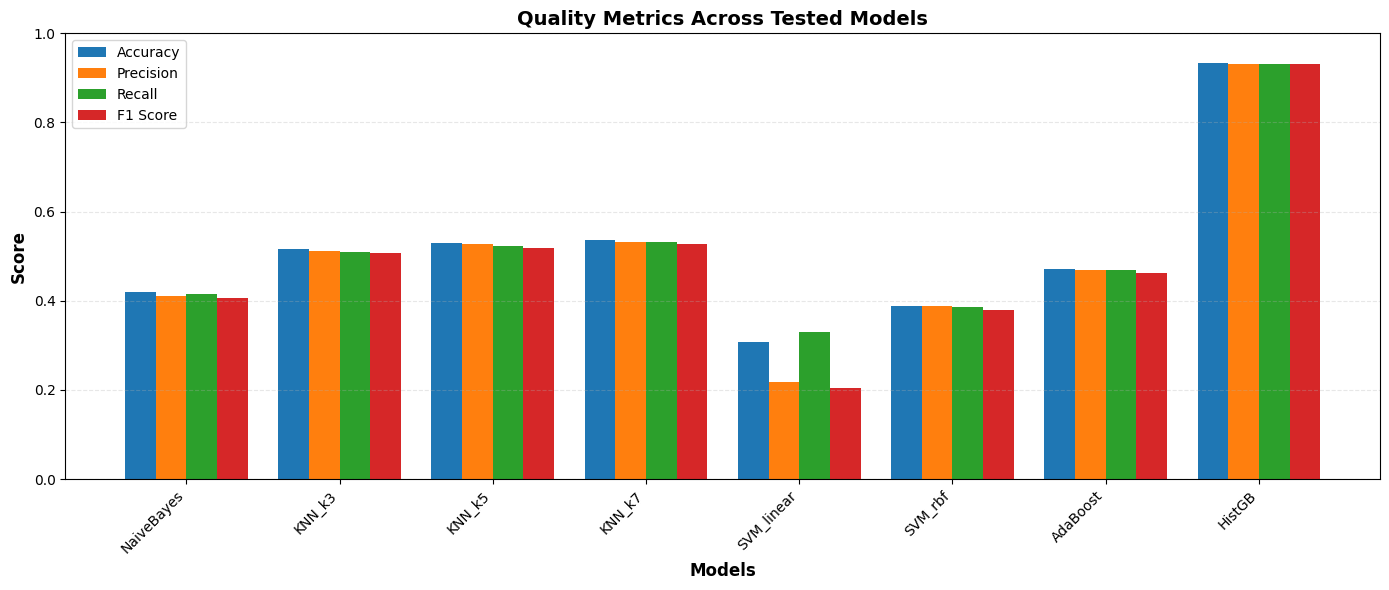

In [16]:
# ============================================================
# VISUALIZATION - MODEL COMPARISON CHART
# ============================================================
# Prepare data for grouped bar chart
x = np.arange(len(results_df))
width = 0.2

metrics = ['Accuracy', 'Precision_macro', 'Recall_macro', 'F1_Score_macro']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot bars for each metric
for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width
    ax.bar(x + offset, results_df[metric], width, label=metric_labels[i])

# Customize plot
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Quality Metrics Across Tested Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.0)

plt.tight_layout()

# Save figure
fig_path = os.path.join("..", "results", "janhavi_model_comparison.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {fig_path}")
print(f"File size: {os.path.getsize(fig_path)} bytes")

plt.show()

Efficiency plot saved to: ..\results\janhavi_efficiency_plot.png
File size: 147422 bytes

Efficiency Analysis:
Fastest Inference: NaiveBayes (0.005756s)
Fastest Training: KNN_k7 (0.013004s)


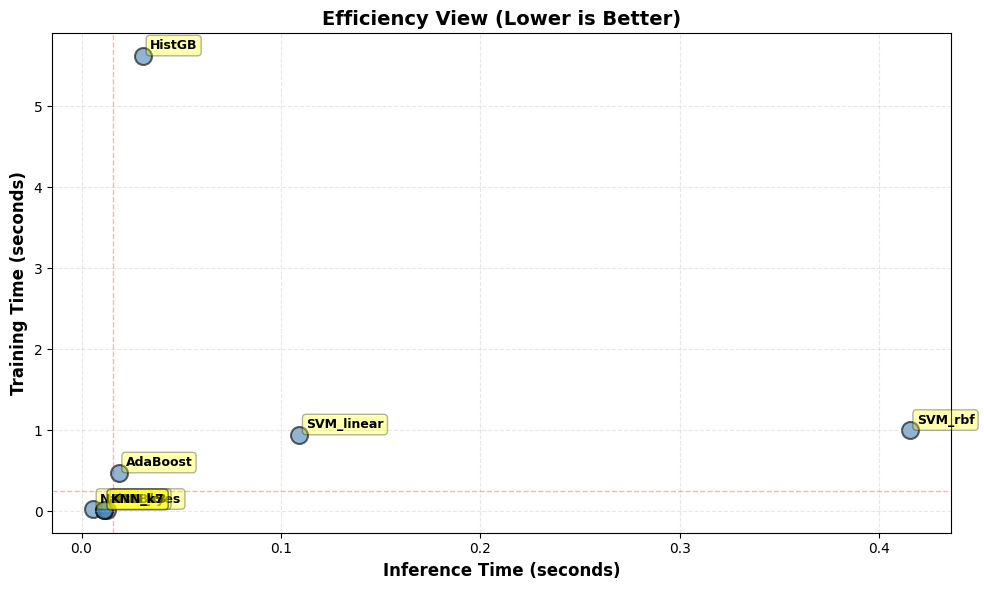

In [17]:
# ============================================================
# VISUALIZATION - EFFICIENCY PLOT
# ============================================================
# Create scatter plot: Training Time vs Inference Time
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(results_df['Inference_Time_s'], results_df['Training_Time_s'], 
           s=150, alpha=0.6, color='steelblue', edgecolors='black', linewidth=1.5)

# Add labels for each point
for idx, row in results_df.iterrows():
    ax.annotate(row['Model'], 
                xy=(row['Inference_Time_s'], row['Training_Time_s']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# Customize plot
ax.set_xlabel('Inference Time (seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Efficiency View (Lower is Better)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Add quadrant lines to visualize "best" region (lower left)
ax.axhline(y=results_df['Training_Time_s'].median(), color='red', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(x=results_df['Inference_Time_s'].median(), color='red', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()

# Save figure
eff_path = os.path.join("..", "results", "janhavi_efficiency_plot.png")
plt.savefig(eff_path, dpi=300, bbox_inches='tight')
print(f"Efficiency plot saved to: {eff_path}")
print(f"File size: {os.path.getsize(eff_path)} bytes")

# Print efficiency insights
print("\nEfficiency Analysis:")
fastest_inference = results_df.loc[results_df['Inference_Time_s'].idxmin()]
fastest_training = results_df.loc[results_df['Training_Time_s'].idxmin()]
print(f"Fastest Inference: {fastest_inference['Model']} ({fastest_inference['Inference_Time_s']:.6f}s)")
print(f"Fastest Training: {fastest_training['Model']} ({fastest_training['Training_Time_s']:.6f}s)")

plt.show()

In [18]:
# ============================================================
# SELECT BEST MODEL & RETRAIN
# ============================================================
# Find model with highest F1 score
best_model_idx = results_df['F1_Score_macro'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1_score = results_df.loc[best_model_idx, 'F1_Score_macro']

print(f"Best Model (by F1 Score): {best_model_name}")
print(f"F1 Score: {best_f1_score:.4f}")

# Retrieve the best model from models dictionary
best_model = models[best_model_name]

# Retrain on reduced training data
print("\nRetraining best model on reduced training data...")
retrain_start = time.time()
best_model.fit(X_train_reduced_scaled, y_train)
retrain_time = time.time() - retrain_start

print(f"Retraining completed in {retrain_time:.4f}s")

# Validate on test set
y_pred_best = best_model.predict(X_test_reduced_scaled)
best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best, average='macro', zero_division=0)
best_recall = recall_score(y_test, y_pred_best, average='macro', zero_division=0)
best_f1_retrained = f1_score(y_test, y_pred_best, average='macro', zero_division=0)

print(f"\nRetrained Model Performance on Test Set:")
print(f"  Accuracy:  {best_accuracy:.4f}")
print(f"  Precision: {best_precision:.4f}")
print(f"  Recall:    {best_recall:.4f}")
print(f"  F1 Score:  {best_f1_retrained:.4f}")


Best Model (by F1 Score): HistGB
F1 Score: 0.9317

Retraining best model on reduced training data...
Retraining completed in 1.6493s

Retrained Model Performance on Test Set:
  Accuracy:  0.9336
  Precision: 0.9318
  Recall:    0.9318
  F1 Score:  0.9317


In [19]:
# ============================================================
# SAVE BEST MODEL
# ============================================================
# Save the best trained model to disk using joblib
model_path = os.path.join("..", "models", "feature_selector.pkl")

# Create models directory if it doesn't exist
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save the best model
joblib.dump(best_model, model_path)
print(f"Best Model saved to: {model_path}")
print(f"Model type: {best_model_name}")
print(f"File size: {os.path.getsize(model_path)} bytes")

# Verify the save by loading and testing
loaded_model = joblib.load(model_path)
y_pred_loaded = loaded_model.predict(X_test_reduced_scaled)
loaded_accuracy = accuracy_score(y_test, y_pred_loaded)
print(f"\nVerification: Loaded model accuracy on test set: {loaded_accuracy:.4f}")
print("✓ Model successfully saved and verified!")


Best Model saved to: ..\models\feature_selector.pkl
Model type: HistGB
File size: 1086240 bytes

Verification: Loaded model accuracy on test set: 0.9336
✓ Model successfully saved and verified!


In [ ]:
# ============================================================
# FEATURE SELECTION
# ============================================================
# TARGET_COL = "trait_label"  # <-- adjust to actual column name
# GENOMIC_COLS = [col for col in df.columns if col.startswith("gene_")]  # adjust pattern

# X = df[GENOMIC_COLS]
# y = df[TARGET_COL]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Train a base model for feature selection
# base_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
# base_model.fit(X_train, y_train)

# # Select important features
# selector = SelectFromModel(base_model, prefit=True)
# selected_features = X_train.columns[selector.get_support()]
# print(f"Selected {len(selected_features)} features out of {len(GENOMIC_COLS)}")

print("TODO: Implement feature selection")

In [ ]:
# ============================================================
# SHAP EXPLANATIONS (XAI)
# ============================================================
# explainer = shap.Explainer(base_model, X_test)
# shap_values = explainer(X_test)
# shap.summary_plot(shap_values, X_test)

# # Feature importance table
# importances = pd.DataFrame({
#     "Feature": X_train.columns,
#     "Importance": base_model.feature_importances_
# }).sort_values("Importance", ascending=False)

# print(importances.head(10))

print("TODO: Generate SHAP plots and importance scores")

In [ ]:
# ============================================================
# SAVE FEATURE SELECTOR & IMPORTANCE
# ============================================================
# --- For Local ---
MODEL_PATH  = os.path.join("..", "models", "feature_selector.pkl")
RESULT_PATH = os.path.join("..", "results", "genomic_feature_importance.csv")

# --- For Colab (uncomment these instead) ---
# MODEL_PATH  = "feature_selector.pkl"
# RESULT_PATH = "genomic_feature_importance.csv"

# joblib.dump(selector, MODEL_PATH)
# print(f"Selector saved → {MODEL_PATH}")

# importances.to_csv(RESULT_PATH, index=False)
# print(f"Feature importance saved → {RESULT_PATH}")

print("TODO: Uncomment to save selector and importance CSV")

In [20]:
import joblib

model = joblib.load("../models/feature_selector.pkl")
print("Model loaded successfully:", type(model))

Model loaded successfully: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
